In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt


Mounted at /content/drive


In [ ]:
decoder = tf.keras.models.load_model('/content/drive/MyDrive/cvae_mnist_decoder.keras')
print("Decoder loaded.")

Decoder loaded.


In [ ]:
latent_dim = 2
num_classes = 10


In [ ]:
def generate_digit_with_decoder(decoder, digit, num_samples=1):
    if digit < 0 or digit > 9:
        raise ValueError("digit must be between 0 and 9")

    z_random = tf.random.normal(shape=(num_samples, latent_dim))

    labels = np.full((num_samples,), digit, dtype=np.int32)
    labels_onehot = keras.utils.to_categorical(labels, num_classes)

    generated = decoder.predict([z_random, labels_onehot])

    for i in range(num_samples):
        plt.figure()
        plt.imshow(generated[i, :, :, 0], cmap='gray')
        plt.axis('off')
        plt.title(f"Generated digit: {digit}")
        plt.show()

Enter a digit (0–9) to generate, or 'q' to quit: 7
Generating digit 7 ...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


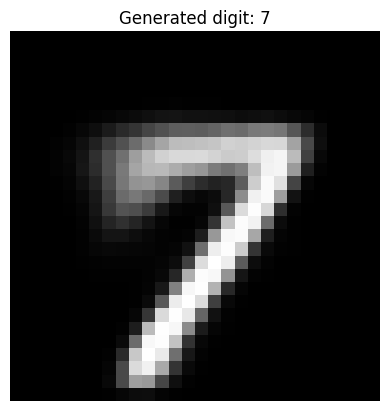

Enter a digit (0–9) to generate, or 'q' to quit: a
Please enter a valid digit between 0 and 9.

Enter a digit (0–9) to generate, or 'q' to quit: q
Exiting.


In [ ]:
 while True:
        user_input = input("Enter a digit (0–9) to generate, or 'q' to quit: ").strip()
        if user_input.lower() == "q":
            print("Exiting.")
            break

        if not user_input.isdigit() or not (0 <= int(user_input) <= 9):
            print("Please enter a valid digit between 0 and 9.\n")
            continue

        digit = int(user_input)
        print(f"Generating digit {digit} ...")
        generate_digit_with_decoder(decoder, digit)